<a href="https://colab.research.google.com/github/hik1ko/Instagramscraper/blob/master/notebooks/Scrape_the_web_agentically_with_Firecrawl_and_LangGraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Install dependencies

First, we need to install the langgraph and firecrawl-py packages.

In [ ]:
%%capture --no-stderr
pip install -U langgraph firecrawl-py -q

## Setup some nice logging so we can see what's happening at all times

In [ ]:
import getpass
from typing import List, Optional, TypedDict, Any
from typing_extensions import Annotated
from operator import or_
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from IPython.display import Image, display
import logging

# === Logging Configuration ===
logger = logging.getLogger()
logger.setLevel(logging.INFO)  # Set the root logger level to INFO

# Remove all handlers associated with the root logger object.
if logger.hasHandlers():
    logger.handlers.clear()

# Create a new handler
handler = logging.StreamHandler()
handler.setLevel(logging.INFO)  # Set handler level to INFO

# Create a formatter and set it for the handler
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
handler.setFormatter(formatter)

# Add the handler to the root logger
logger.addHandler(handler)
# === End of Logging Configuration ===

def first_non_null(a, b):
    return a if a is not None else b


## Make sure we set our Firecrawl API key

In [ ]:
FIRECRAWL_API_KEY = getpass.getpass("Firecrawl API Key: ")

## Define our LangGraph agent's state schema

This is so it knows what to keep track of when it's running from node to node.

In [ ]:
# Define the InputState schema
class InputState(TypedDict):
    url: str
    keyword: str

# Define the OverallState schema with reducers
class OverallState(TypedDict):
    urls: List[str]
    current_url_index: int
    total_urls: int
    urls_to_scrape: List[str]
    extracted_info: Annotated[Optional[str], first_non_null]
    extracted_from_url: Annotated[Optional[str], first_non_null]
    is_information_found: Annotated[Optional[bool], or_]
    keyword: str


## Define agent nodes

We designate a first_node that is just a placeholder just to see what our state (data) looks like in the beginning.

In [ ]:
def first_node(state: InputState) -> OverallState:
    logging.info("Executing node: first_node")
    return {
        "urls": [state["url"]],
        "current_url_index": 0,
        "total_urls": 0,
        "urls_to_scrape": [],
        "keyword": state["keyword"],
        "extracted_info": None,
        "extracted_from_url": None,
        "is_information_found": False,
    }


Our second node would be the one that finds the sitemap from the website we give the agent. This will leverage Firecrawl to do so.

In [ ]:
from firecrawl import FirecrawlApp

def get_sitemap(state: OverallState, config):
    logging.info("Executing node: get_sitemap")
    api_key = config.get("configurable", {}).get("firecrawl_api_key")
    if not api_key:
        logging.error("Firecrawl API key is missing in the configuration.")
        raise ValueError("Firecrawl API key is missing in the configuration.")

    app = FirecrawlApp(api_key=api_key)

    # Map the website to get the list of URLs
    map_result = app.map_url(state["urls"][0])
    logging.info(f"Map result: {map_result}")

    # Handle the new response format which is a dictionary
    if isinstance(map_result, dict):
        if map_result.get('success') and isinstance(map_result.get('links'), list):
            sitemap = map_result['links']
            state["urls"] = sitemap
            state["total_urls"] = len(sitemap)
            logging.info(f"Found {len(sitemap)} URLs to scrape.")
        else:
            logging.error(f"Error: Invalid response structure in map_result: {map_result}")
            state["urls"] = []
    # Keep the original list handling for backward compatibility
    elif isinstance(map_result, list) and len(map_result) > 0:
        sitemap = map_result
        state["urls"] = sitemap
        state["total_urls"] = len(sitemap)
        logging.info(f"Found {len(sitemap)} URLs to scrape.")
    else:
        logging.error(f"Error: Unexpected format in map_result: {map_result}")
        state["urls"] = []

    return state

Next, we define a node that manages scraping. Why is called "manager"? It's because we want our agent to take three URLs from the sitemap at a time to scrape and extract information, then if it has to do that again, then the manager will facilitate that.

In [ ]:
def scrape_manager(state: OverallState) -> OverallState:
    logging.info("Executing node: scrape_manager")
    total_urls = state.get("total_urls", 0)
    current_index = state["current_url_index"]
    next_index = min(current_index + 3, total_urls)
    urls_to_scrape = state["urls"][current_index:next_index]
    state["current_url_index"] = next_index  # Update the current index
    state["urls_to_scrape"] = urls_to_scrape  # Store the URLs to scrape

    if total_urls > 0:
        progress = (current_index / total_urls) * 100
        logging.info(f"Progress: {current_index}/{total_urls} URLs processed ({progress:.2f}%)")
    return state

# Function to return Send objects to scraper nodes
def continue_to_scraper(state: OverallState):
    logging.info(f"Preparing to scrape URLs {state['current_url_index'] - len(state['urls_to_scrape'])} to {state['current_url_index'] - 1}")
    # Return list of Send objects to 'scraper' node
    return [Send("scraper", {"url": url, "keyword": state["keyword"]}) for url in state["urls_to_scrape"]]


As you can see, we also allow this node to directly send a private state (using Send from langgraph module) so that it can fire off three parallel scraper nodes at once. We haven't declared our scraper node yet, but that's the plan.

Now, the scraper node. This node will actually scrape the URL (using Firecrawl). We want to run multiple of these at once

In [ ]:
from firecrawl import FirecrawlApp

def scraper(state: OverallState, config):
    url = state["url"]
    keyword = state["keyword"]
    logging.info(f"Executing node: scraper for URL: {url}")
    api_key = config.get("configurable", {}).get("firecrawl_api_key")
    if not api_key:
        logging.error("Firecrawl API key is missing in the configuration.")
        raise ValueError("Firecrawl API key is missing in the configuration.")

    app = FirecrawlApp(api_key=api_key)

    # Scrape the URL and get markdown
    try:
        logging.info(f"Started scraping: {url}")
        scrape_result = app.scrape_url(url, params={'formats': ['markdown']})
        logging.info(f"Scraped URL: {url}")
    except Exception as e:
        logging.error(f"Exception occurred while scraping URL: {url}. Error: {e}")
        scrape_result = {}

    if isinstance(scrape_result, dict):
        markdown = scrape_result.get("markdown", "")
        # Check if keyword is in markdown
        if markdown and keyword in markdown:
            # Information found
            return {
                "extracted_info": markdown,
                "extracted_from_url": url,
                "is_information_found": True
            }
        else:
            # Information not found
            return {"is_information_found": False}
    else:
        logging.warning(f"Failed to scrape URL: {url}")
        return {"is_information_found": False}


The next node would try to see if the information we're looking for was found in the scraped URL. Remember this: each scraper we run will be evaluated all together at the same time once they're all done (we call this fan-in, and when the scraper manager fires off three scraper nodes to run, that was called "fan-out")

In [ ]:
def evaluate(state: OverallState):
    logging.info("Executing node: evaluate")
    # Logic is handled in the routing function
    return state

# Conditional routing function for evaluate node
def evaluate_routing(state: OverallState):
    if state.get("is_information_found", False):
        logging.info(f"Information found in URL: {state.get('extracted_from_url')}")
        logging.info("Terminating graph execution.")
        return "END"
    elif state["current_url_index"] < len(state["urls"]):
        logging.info("Information not found, continuing to scrape next batch.")
        return "scrape_manager"
    else:
        logging.info("No more URLs to scrape, terminating graph execution.")
        return "END"


## Before we can run our agent, compile it

In [ ]:
# Build the graph with configuration schema
class ConfigSchema(TypedDict):
    firecrawl_api_key: str

builder = StateGraph(OverallState, input=InputState, config_schema=ConfigSchema)

builder.add_node("first_node", first_node)
builder.add_node("get_sitemap", get_sitemap)
builder.add_node("scrape_manager", scrape_manager)
builder.add_node("scraper", scraper)
builder.add_node("evaluate", evaluate)

# Add edges between nodes
builder.add_edge(START, "first_node")
builder.add_edge("first_node", "get_sitemap")
builder.add_edge("get_sitemap", "scrape_manager")

# Add conditional edges from scrape_manager to scraper nodes
builder.add_conditional_edges("scrape_manager", continue_to_scraper, ["scraper"])

builder.add_edge("scraper", "evaluate")

# Add conditional edge from evaluate node with explicit mapping
builder.add_conditional_edges(
    "evaluate",
    evaluate_routing,
    {"END": END, "scrape_manager": "scrape_manager"}
)

# Compile the graph
graph = builder.compile()


## For better understanding of what the heck is going on, see it

LangGraph has built-in mermaid chart generator (neat!)

You'll see how easy to understand it is once you see the chart (I promise)

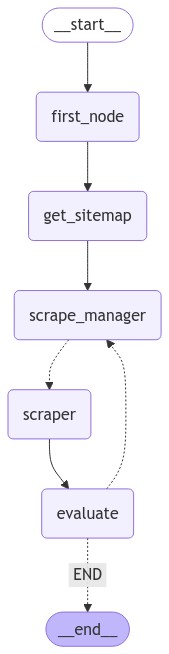

In [ ]:
# Visualize the graph
display(Image(graph.get_graph().draw_mermaid_png()))

## Run this baby

This is the moment of truth. We shall now run it.

Our agent is given a task to find out which page has info on "Shelburne Parka" but we're just going to give it the generic root domain from canadagoose.com (it's a clothing company. I'm too poor to own anything from them)

You can imagine how flexible this could be: here, we're looking for an exact keyword match, but you can always swap for an LLM and do extraction here!

In [2]:
config = {"configurable": {"firecrawl_api_key": "fc-2e22e643743249b58cc7afede186cdb8"}, "recursion_limit": 50}

input_state = {
    "url": "https://www.asaxiy.uz/",
    "keyword": "honor-x9c-8256-titanium-black"
}

result = graph.invoke(input_state, config=config)

NameError: name 'graph' is not defined

There. It found the site that contains the keyword. Imagine running this over a huge .csv and just sit back and let the data come in!

One caveat though: Firecrawl's rate limit is pretty low: 20 scrapes per minute, so I kinda cooked this tutorial for an easy example. Try it with something that requires deeper search (like an unindexed documentation site), and put in exponential back-offs so it doesn't hit rate limit.

In [3]:
# Build the graph with configuration schema
class ConfigSchema(TypedDict):
    firecrawl_api_key: str

builder = StateGraph(OverallState, input=InputState, config_schema=ConfigSchema)

builder.add_node("first_node", first_node)
builder.add_node("get_sitemap", get_sitemap)
builder.add_node("scrape_manager", scrape_manager)
builder.add_node("scraper", scraper)
builder.add_node("evaluate", evaluate)

# Add edges between nodes
builder.add_edge(START, "first_node")
builder.add_edge("first_node", "get_sitemap")
builder.add_edge("get_sitemap", "scrape_manager")

# Add conditional edges from scrape_manager to scraper nodes
builder.add_conditional_edges("scrape_manager", continue_to_scraper, ["scraper"])

builder.add_edge("scraper", "evaluate")

# Add conditional edge from evaluate node with explicit mapping
builder.add_conditional_edges(
    "evaluate",
    evaluate_routing,
    {"END": END, "scrape_manager": "scrape_manager"}
)

# Compile the graph
graph = builder.compile()

NameError: name 'TypedDict' is not defined

In [4]:
import getpass
from typing import List, Optional, TypedDict, Any
from typing_extensions import Annotated
from operator import or_
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from IPython.display import Image, display
import logging

# === Logging Configuration ===
logger = logging.getLogger()
logger.setLevel(logging.INFO)  # Set the root logger level to INFO

# Remove all handlers associated with the root logger object.
if logger.hasHandlers():
    logger.handlers.clear()

# Create a new handler
handler = logging.StreamHandler()
handler.setLevel(logging.INFO)  # Set handler level to INFO

# Create a formatter and set it for the handler
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
handler.setFormatter(formatter)

# Add the handler to the root logger
logger.addHandler(handler)
# === End of Logging Configuration ===

def first_non_null(a, b):
    return a if a is not None else b

ModuleNotFoundError: No module named 'langgraph'

In [5]:
# Build the graph with configuration schema
class ConfigSchema(TypedDict):
    firecrawl_api_key: str

builder = StateGraph(OverallState, input=InputState, config_schema=ConfigSchema)

builder.add_node("first_node", first_node)
builder.add_node("get_sitemap", get_sitemap)
builder.add_node("scrape_manager", scrape_manager)
builder.add_node("scraper", scraper)
builder.add_node("evaluate", evaluate)

# Add edges between nodes
builder.add_edge(START, "first_node")
builder.add_edge("first_node", "get_sitemap")
builder.add_edge("get_sitemap", "scrape_manager")

# Add conditional edges from scrape_manager to scraper nodes
builder.add_conditional_edges("scrape_manager", continue_to_scraper, ["scraper"])

builder.add_edge("scraper", "evaluate")

# Add conditional edge from evaluate node with explicit mapping
builder.add_conditional_edges(
    "evaluate",
    evaluate_routing,
    {"END": END, "scrape_manager": "scrape_manager"}
)

# Compile the graph
graph = builder.compile()

NameError: name 'StateGraph' is not defined

In [6]:
pip install -U langgraph firecrawl-py -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.2/440.2 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.5/216.5 kB 19.2 MB/s eta 0:00:00


In [7]:
import getpass
from typing import List, Optional, TypedDict, Any
from typing_extensions import Annotated
from operator import or_
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from IPython.display import Image, display
import logging

# === Logging Configuration ===
logger = logging.getLogger()
logger.setLevel(logging.INFO)  # Set the root logger level to INFO

# Remove all handlers associated with the root logger object.
if logger.hasHandlers():
    logger.handlers.clear()

# Create a new handler
handler = logging.StreamHandler()
handler.setLevel(logging.INFO)  # Set handler level to INFO

# Create a formatter and set it for the handler
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
handler.setFormatter(formatter)

# Add the handler to the root logger
logger.addHandler(handler)
# === End of Logging Configuration ===

def first_non_null(a, b):
    return a if a is not None else b

In [8]:
# Define the InputState schema
class InputState(TypedDict):
    url: str
    keyword: str

# Define the OverallState schema with reducers
class OverallState(TypedDict):
    urls: List[str]
    current_url_index: int
    total_urls: int
    urls_to_scrape: List[str]
    extracted_info: Annotated[Optional[str], first_non_null]
    extracted_from_url: Annotated[Optional[str], first_non_null]
    is_information_found: Annotated[Optional[bool], or_]
    keyword: str

In [9]:
def first_node(state: InputState) -> OverallState:
    logging.info("Executing node: first_node")
    return {
        "urls": [state["url"]],
        "current_url_index": 0,
        "total_urls": 0,
        "urls_to_scrape": [],
        "keyword": state["keyword"],
        "extracted_info": None,
        "extracted_from_url": None,
        "is_information_found": False,
    }

In [10]:
from firecrawl import FirecrawlApp

def get_sitemap(state: OverallState, config):
    logging.info("Executing node: get_sitemap")
    api_key = config.get("configurable", {}).get("firecrawl_api_key")
    if not api_key:
        logging.error("Firecrawl API key is missing in the configuration.")
        raise ValueError("Firecrawl API key is missing in the configuration.")

    app = FirecrawlApp(api_key=api_key)

    # Map the website to get the list of URLs
    map_result = app.map_url(state["urls"][0])
    logging.info(f"Map result: {map_result}")

    # Handle the new response format which is a dictionary
    if isinstance(map_result, dict):
        if map_result.get('success') and isinstance(map_result.get('links'), list):
            sitemap = map_result['links']
            state["urls"] = sitemap
            state["total_urls"] = len(sitemap)
            logging.info(f"Found {len(sitemap)} URLs to scrape.")
        else:
            logging.error(f"Error: Invalid response structure in map_result: {map_result}")
            state["urls"] = []
    # Keep the original list handling for backward compatibility
    elif isinstance(map_result, list) and len(map_result) > 0:
        sitemap = map_result
        state["urls"] = sitemap
        state["total_urls"] = len(sitemap)
        logging.info(f"Found {len(sitemap)} URLs to scrape.")
    else:
        logging.error(f"Error: Unexpected format in map_result: {map_result}")
        state["urls"] = []

    return state

In [11]:
def scrape_manager(state: OverallState) -> OverallState:
    logging.info("Executing node: scrape_manager")
    total_urls = state.get("total_urls", 0)
    current_index = state["current_url_index"]
    next_index = min(current_index + 3, total_urls)
    urls_to_scrape = state["urls"][current_index:next_index]
    state["current_url_index"] = next_index  # Update the current index
    state["urls_to_scrape"] = urls_to_scrape  # Store the URLs to scrape

    if total_urls > 0:
        progress = (current_index / total_urls) * 100
        logging.info(f"Progress: {current_index}/{total_urls} URLs processed ({progress:.2f}%)")
    return state

# Function to return Send objects to scraper nodes
def continue_to_scraper(state: OverallState):
    logging.info(f"Preparing to scrape URLs {state['current_url_index'] - len(state['urls_to_scrape'])} to {state['current_url_index'] - 1}")
    # Return list of Send objects to 'scraper' node
    return [Send("scraper", {"url": url, "keyword": state["keyword"]}) for url in state["urls_to_scrape"]]

In [12]:
from firecrawl import FirecrawlApp

def scraper(state: OverallState, config):
    url = state["url"]
    keyword = state["keyword"]
    logging.info(f"Executing node: scraper for URL: {url}")
    api_key = config.get("configurable", {}).get("firecrawl_api_key")
    if not api_key:
        logging.error("Firecrawl API key is missing in the configuration.")
        raise ValueError("Firecrawl API key is missing in the configuration.")

    app = FirecrawlApp(api_key=api_key)

    # Scrape the URL and get markdown
    try:
        logging.info(f"Started scraping: {url}")
        scrape_result = app.scrape_url(url, params={'formats': ['markdown']})
        logging.info(f"Scraped URL: {url}")
    except Exception as e:
        logging.error(f"Exception occurred while scraping URL: {url}. Error: {e}")
        scrape_result = {}

    if isinstance(scrape_result, dict):
        markdown = scrape_result.get("markdown", "")
        # Check if keyword is in markdown
        if markdown and keyword in markdown:
            # Information found
            return {
                "extracted_info": markdown,
                "extracted_from_url": url,
                "is_information_found": True
            }
        else:
            # Information not found
            return {"is_information_found": False}
    else:
        logging.warning(f"Failed to scrape URL: {url}")
        return {"is_information_found": False}

In [13]:
def evaluate(state: OverallState):
    logging.info("Executing node: evaluate")
    # Logic is handled in the routing function
    return state

# Conditional routing function for evaluate node
def evaluate_routing(state: OverallState):
    if state.get("is_information_found", False):
        logging.info(f"Information found in URL: {state.get('extracted_from_url')}")
        logging.info("Terminating graph execution.")
        return "END"
    elif state["current_url_index"] < len(state["urls"]):
        logging.info("Information not found, continuing to scrape next batch.")
        return "scrape_manager"
    else:
        logging.info("No more URLs to scrape, terminating graph execution.")
        return "END"

In [14]:
# Build the graph with configuration schema
class ConfigSchema(TypedDict):
    firecrawl_api_key: str

builder = StateGraph(OverallState, input=InputState, config_schema=ConfigSchema)

builder.add_node("first_node", first_node)
builder.add_node("get_sitemap", get_sitemap)
builder.add_node("scrape_manager", scrape_manager)
builder.add_node("scraper", scraper)
builder.add_node("evaluate", evaluate)

# Add edges between nodes
builder.add_edge(START, "first_node")
builder.add_edge("first_node", "get_sitemap")
builder.add_edge("get_sitemap", "scrape_manager")

# Add conditional edges from scrape_manager to scraper nodes
builder.add_conditional_edges("scrape_manager", continue_to_scraper, ["scraper"])

builder.add_edge("scraper", "evaluate")

# Add conditional edge from evaluate node with explicit mapping
builder.add_conditional_edges(
    "evaluate",
    evaluate_routing,
    {"END": END, "scrape_manager": "scrape_manager"}
)

# Compile the graph
graph = builder.compile()

/tmp/ipython-input-14-1057583153.py:5: LangGraphDeprecatedSinceV05: `input` is deprecated and will be removed. Please use `input_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  builder = StateGraph(OverallState, input=InputState, config_schema=ConfigSchema)


In [15]:
config = {"configurable": {"firecrawl_api_key": "fc-2e22e643743249b58cc7afede186cdb8"}, "recursion_limit": 50}

input_state = {
    "url": "https://www.asaxiy.uz/",
    "keyword": "honor-x9c-8256-titanium-black"
}

result = graph.invoke(input_state, config=config)

2025-07-02 07:20:35,494 - INFO - Executing node: first_node
2025-07-02 07:20:35,495 - INFO - Executing node: get_sitemap
2025-07-02 07:20:50,091 - INFO - Map result: success=True links=['https://asaxiy.uz', 'https://asaxiy.uz/uz/product/tekstovydelitel-highlighter-hd5825-siniy', 'https://asaxiy.uz/product/paulo-coelho-the-alchemist', 'https://asaxiy.uz/product/naushniki-sony-wf-1000xm5-rozovyy', 'https://asaxiy.uz/uz/product/naushniki-tws-sony-wf-c510-jeltyy', 'https://asaxiy.uz/uz/product/besprovodnye-naushniki-sony-wh-ch720n-siniy', 'https://asaxiy.uz/uz/product/varochnaya-panel-artel-premio-a64-1730', 'https://asaxiy.uz/uz/product/zara-orchid-180-ml-parfyum-dlya-jenshchin', 'https://asaxiy.uz/uz/product/besprovodnye-naushniki-sony-wh-1000xm5-rozovyy', 'https://asaxiy.uz/product/filtr-panasonic-f-zxfd70z', 'https://asaxiy.uz/uz/product/filtr-panasonic-f-zxfd70z', 'https://asaxiy.uz/product/tekstovydelitel-cat-claw-rozovyy', 'https://asaxiy.uz/uz/product/tekstovydelitel-cat-claw-rozov